In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from matplotlib import pyplot as plt

In [2]:
dataset = pd.read_csv("../data/train.csv")
independent_variables = dataset.drop(columns=["price"])
dependent_variable = dataset["price"]
seed=42

In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 72 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   wheelbase             235 non-null    float64
 1   carlength             235 non-null    float64
 2   carwidth              235 non-null    float64
 3   carheight             235 non-null    float64
 4   curbweight            235 non-null    int64  
 5   cylindernumber        235 non-null    float64
 6   enginesize            235 non-null    int64  
 7   compressionratio      235 non-null    float64
 8   horsepower            235 non-null    float64
 9   peakrpm               235 non-null    int64  
 10  citympg               235 non-null    int64  
 11  highwaympg            235 non-null    int64  
 12  price                 235 non-null    float64
 13  carname_Nissan        235 non-null    float64
 14  carname_alfa-romero   235 non-null    float64
 15  carname_audi          235 non-null

In [4]:
# Scale the data
def z_score_scale(dataset, feature_name):
    feature = list(dataset[feature_name])
    mu = np.mean(feature)
    std = np.std(feature)
    z_score = [round((i - mu) / std, 2) for i in feature]

    dataset[feature_name] = z_score

features_to_scale = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "compressionratio", "horsepower", "peakrpm", "highwaympg", "citympg"]
# To avoid data leakage, we first split the data into train and test sets. I will use 90% train, and 20% test set.
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=0.2, shuffle=True)

# Scale train
for i in X_train:
    if i in features_to_scale:
        z_score_scale(X_train, i)

# Scale test
for i in X_test:
    if i in features_to_scale:
        z_score_scale(X_test, i)


In [5]:
# Feature selection
# When we have many features, we need to check which feature is important for our target. 
# Here I use F regression and check P values which tells us how important the feature is. 
p_values = {}
for f in independent_variables:
    p_value = f_regression(dataset[f].values.reshape(-1, 1), dependent_variable)[1]
    p_values[f] = p_value

In [6]:
p_values

{'wheelbase': array([1.75163562e-22]),
 'carlength': array([1.27109469e-32]),
 'carwidth': array([2.52771252e-46]),
 'carheight': array([0.05917182]),
 'curbweight': array([1.3043024e-63]),
 'cylindernumber': array([9.51302782e-36]),
 'enginesize': array([7.85300234e-75]),
 'compressionratio': array([0.18333346]),
 'horsepower': array([3.17720563e-53]),
 'peakrpm': array([0.10541162]),
 'citympg': array([1.78757526e-32]),
 'highwaympg': array([4.97683986e-34]),
 'carname_Nissan': array([0.33094276]),
 'carname_alfa-romero': array([0.58206005]),
 'carname_audi': array([0.09540764]),
 'carname_bmw': array([4.02572469e-07]),
 'carname_buick': array([1.91629722e-17]),
 'carname_chevrolet': array([0.11412886]),
 'carname_dodge': array([0.02466625]),
 'carname_honda': array([0.00821734]),
 'carname_isuzu': array([0.28436277]),
 'carname_jaguar': array([7.16824046e-07]),
 'carname_maxda': array([0.17622072]),
 'carname_mazda': array([0.4988285]),
 'carname_mercury': array([0.65577469]),
 'car

In [7]:
# Helper functions
def calculate_metrics(y_test, preds):
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)


    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2) Score: {r2:.2f}")

    return (mae, mse, rmse, r2)
    
def plot_pred_vs_true(y_test, preds):
    MIN_VALUE = 0
    MAX_VALUE = max(y_test)
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, preds)
    plt.plot([MIN_VALUE, MAX_VALUE], [MIN_VALUE, MAX_VALUE], '--k', label="Correct prediction")

    plt.title("Predicted vs. True Plot")
    plt.xlabel('True Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.tight_layout()

def plot_residual(y_test, preds):
    residuals = y_test - preds
    plt.figure(figsize=(8, 8))
    plt.xlabel('Price')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    plt.scatter(preds, residuals)
    plt.axhline(0, linestyle="--")

In [8]:
X_train.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,...,color_green,color_lime,color_maroon,color_navy,color_olive,color_purple,color_silver,color_teal,color_white,color_yellow
count,188.000000,1.880000e+02,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,...,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,-0.000798,-9.448707e-18,-0.001862,-0.000798,-0.000266,4.287234,-0.000106,-0.000160,-0.000319,-0.000957,...,0.058511,0.058511,0.031915,0.085106,0.079787,0.058511,0.053191,0.074468,0.058511,0.111702
std,1.002623,1.002111e+00,1.002728,1.002481,1.003311,0.893498,1.003234,1.002546,1.002845,1.002279,...,0.235333,0.235333,0.176243,0.279785,0.271687,0.235333,0.225014,0.263232,0.235333,0.315841
min,-2.010000,-2.740000e+00,-2.700000,-1.930000,-2.120000,2.000000,-1.700000,-0.780000,-1.550000,-1.990000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.660000,-5.900000e-01,-0.850000,-0.810000,-0.762500,4.000000,-0.697500,-0.410000,-0.900000,-0.640000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-0.320000,-4.000000e-02,-0.150000,0.080000,-0.230000,4.000000,-0.355000,-0.290000,-0.175000,-0.020000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.340000,3.900000e-01,0.400000,0.760000,0.645000,4.000000,0.480000,-0.190000,0.450000,0.810000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.840000,2.960000e+00,3.150000,2.490000,3.200000,8.000000,5.020000,3.190000,3.130000,3.100000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
simple_linear_model = LinearRegression()
simple_linear_model.fit(X_train, y_train)
simple_linear_model_preds = simple_linear_model.predict(X_test)
simple_linear_model_preds_on_train = simple_linear_model.predict(X_train)

print("Train set performance: \n")
mae, mse, rmse, r2 = calculate_metrics(y_test=y_train, preds=simple_linear_model_preds_on_train)
print("\nTest set performance: \n")
calculate_metrics(y_test=y_test, preds=simple_linear_model_preds)


Train set performance: 

Mean Absolute Error (MAE): 971.17
Mean Squared Error (MSE): 1767791.70
Root Mean Squared Error (RMSE): 1329.58
R-squared (R2) Score: 0.96

Test set performance: 

Mean Absolute Error (MAE): 2134.13
Mean Squared Error (MSE): 13015535.12
Root Mean Squared Error (RMSE): 3607.70
R-squared (R2) Score: 0.86


(2134.128778506104, 13015535.116808617, 3607.704965321945, 0.8627315543228238)

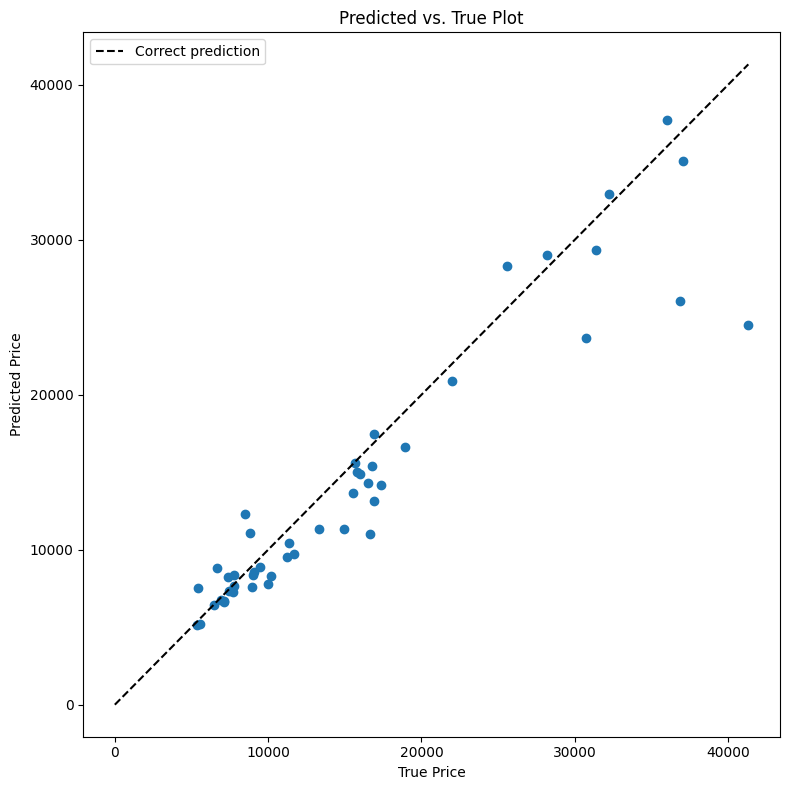

In [10]:
plot_pred_vs_true(y_test, simple_linear_model_preds)

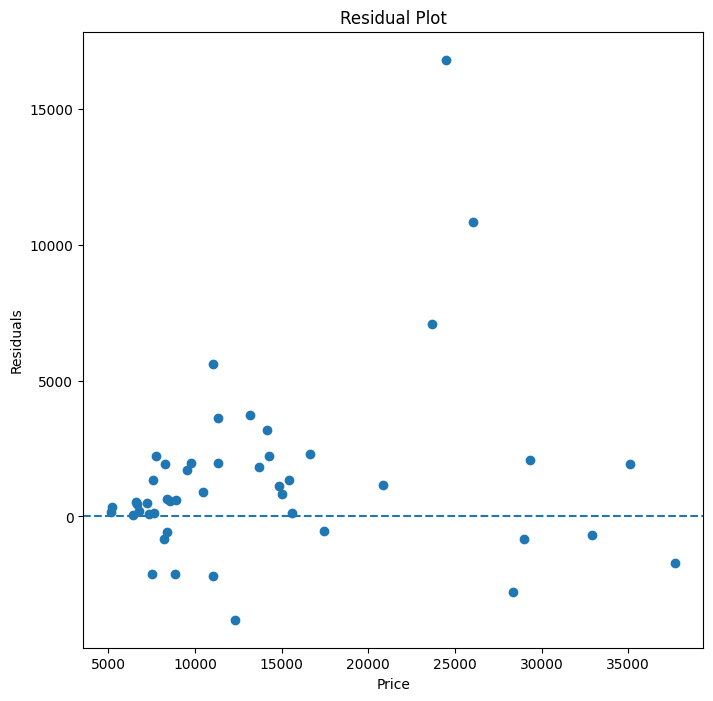

In [11]:
plot_residual(y_test, simple_linear_model_preds)

In [12]:
from sklearn.preprocessing import power_transform

X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=0.2, shuffle=True)
numeric_features = [
    "wheelbase",
    "carlength",
    "carwidth",
    "carheight",
    "curbweight",
    "enginesize",
    "compressionratio",
    "horsepower",
    "citympg",
    "highwaympg",
]

X_train[numeric_features] = power_transform(X_train[numeric_features], method='yeo-johnson', standardize=True, copy=True)
X_test[numeric_features] = power_transform(X_test[numeric_features], method='yeo-johnson', standardize=True, copy=True)

In [13]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 188 entries, 117 to 102
Data columns (total 71 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   wheelbase             188 non-null    float64
 1   carlength             188 non-null    float64
 2   carwidth              188 non-null    float64
 3   carheight             188 non-null    float64
 4   curbweight            188 non-null    float64
 5   cylindernumber        188 non-null    float64
 6   enginesize            188 non-null    float64
 7   compressionratio      188 non-null    float64
 8   horsepower            188 non-null    float64
 9   peakrpm               188 non-null    int64  
 10  citympg               188 non-null    float64
 11  highwaympg            188 non-null    float64
 12  carname_Nissan        188 non-null    float64
 13  carname_alfa-romero   188 non-null    float64
 14  carname_audi          188 non-null    float64
 15  carname_bmw           188 non-null   

In [14]:
pwr_linear_model_preds = LinearRegression()
pwr_linear_model_preds.fit(X_train, y_train)

pwr_preds_on_train = pwr_linear_model_preds.predict(X_train)
pwr_preds = pwr_linear_model_preds.predict(X_test)
print("Train set performance: \n")
calculate_metrics(y_test=y_train, preds=pwr_preds_on_train)
print("\nTest set performance: \n")
calculate_metrics(y_test=y_test, preds=pwr_preds)

Train set performance: 

Mean Absolute Error (MAE): 1049.95
Mean Squared Error (MSE): 2038361.41
Root Mean Squared Error (RMSE): 1427.71
R-squared (R2) Score: 0.96

Test set performance: 

Mean Absolute Error (MAE): 2548.72
Mean Squared Error (MSE): 18078549.22
Root Mean Squared Error (RMSE): 4251.89
R-squared (R2) Score: 0.81


(2548.723916059933, 18078549.217706993, 4251.887724024118, 0.8093344354310761)

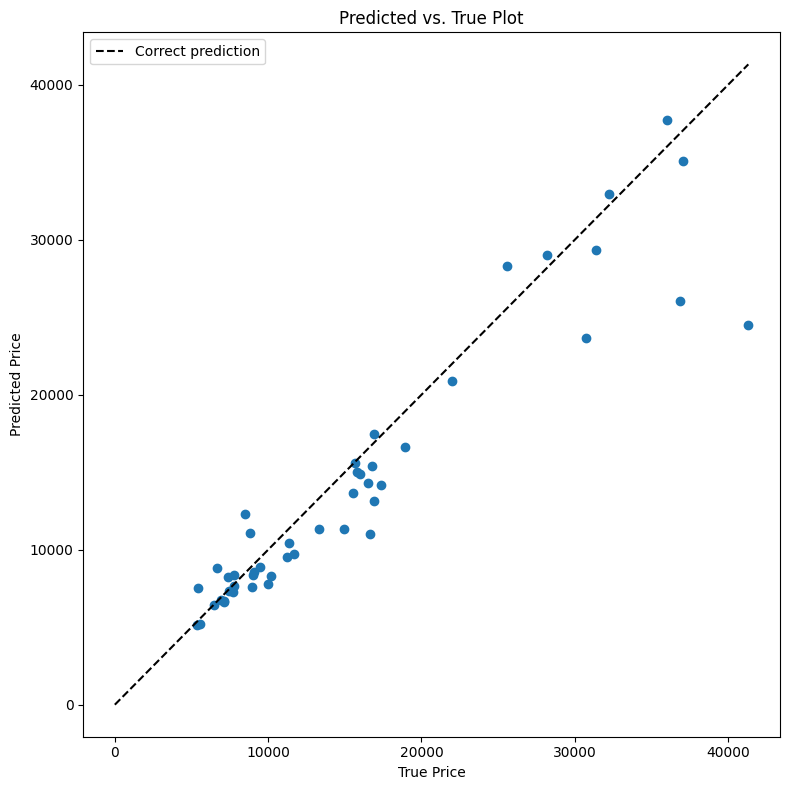

In [15]:
plot_pred_vs_true(y_test, simple_linear_model_preds)

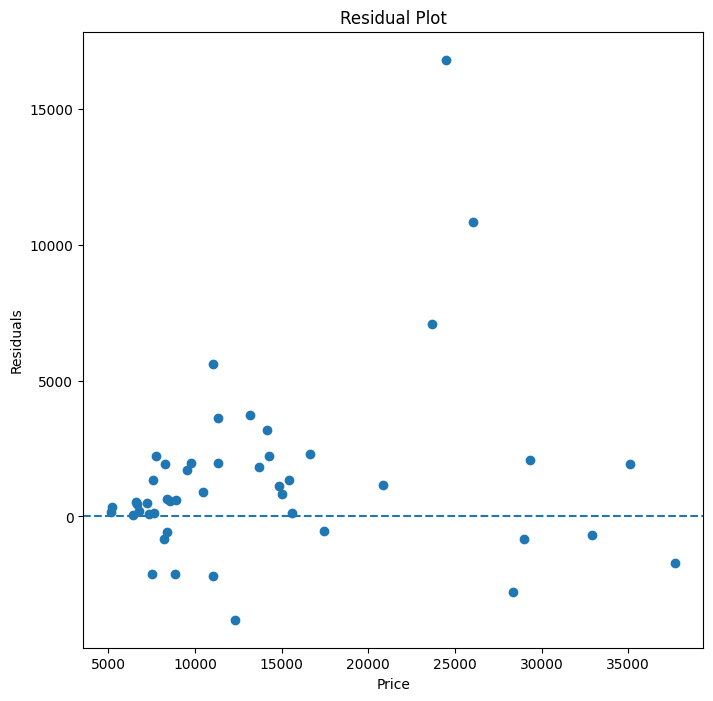

In [16]:
plot_residual(y_test, simple_linear_model_preds)